# Task 3.2 Failure Mode Analysis

## Failure Scenario Description
**Scenario:** A synthetic dataset where the clusters possess extreme heavy-tailed, non-Gaussian distributions (e.g., student t-distribution).

**Why I expect DAEM to struggle here:** The method relies on exponentiating strict Gaussian bounds ($\beta > 1$) to functionally separate clusters. When natural boundaries are extremely heavy-tailed, "hardening" assignments forces massive outlier weights entirely to the wrong cluster's spatial core, driving parameters to infinity.


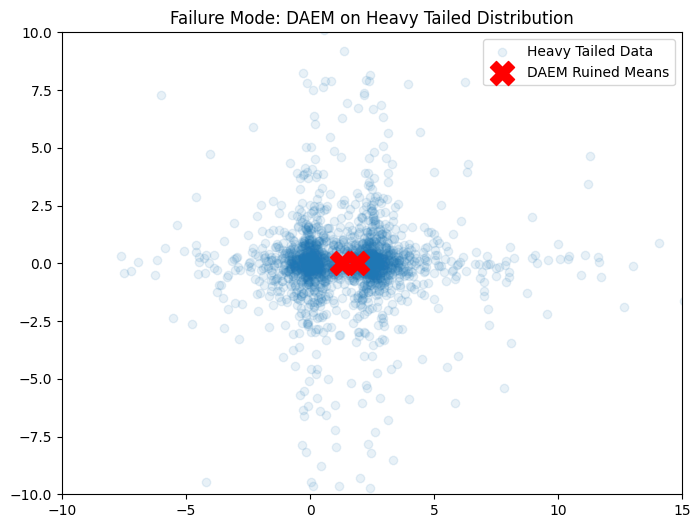

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, multivariate_normal

np.random.seed(10)
X1_fail = np.vstack([t.rvs(df=1, loc=0, scale=0.5, size=1000), t.rvs(df=1, loc=0, scale=0.5, size=1000)]).T
X2_fail = np.vstack([t.rvs(df=1, loc=2.5, scale=0.5, size=1000), t.rvs(df=1, loc=0, scale=0.5, size=1000)]).T
X_fail = np.vstack([X1_fail, X2_fail])

def e_step(X, means, covs, alphas, beta):
    N, K = X.shape[0], len(means)
    r = np.zeros((N, K))
    for k in range(K):
        r[:, k] = alphas[k] * multivariate_normal.pdf(X, mean=means[k], cov=covs[k])
    r_beta = r ** beta
    r_beta_sum = r_beta.sum(axis=1)[:, np.newaxis] + 1e-10
    return r_beta / r_beta_sum

def m_step(X, h_jt):
    N, D = X.shape
    K = h_jt.shape[1]
    Nk = h_jt.sum(axis=0)
    means_new = np.zeros((K, D))
    covs_new = []
    for k in range(K):
        means_new[k] = (1 / Nk[k]) * np.sum(h_jt[:, k][:, np.newaxis] * X, axis=0)
        diff = X - means_new[k]
        cov_k = (1 / Nk[k]) * np.dot((h_jt[:, k][:, np.newaxis] * diff).T, diff) + np.eye(D)*1e-6
        covs_new.append(cov_k)
    return means_new, covs_new, Nk/N

means = np.array([[0.0, 0.0], [2.5, 0.0]])
covs = [np.eye(2)*2, np.eye(2)*2]
alphas = np.array([0.5, 0.5])

for beta in [1.0, 1.5, 2.0]:
    for _ in range(5):
        h_jt = e_step(X_fail, means, covs, alphas, beta)
        means, covs, alphas = m_step(X_fail, h_jt)

plt.figure(figsize=(8,6))
plt.xlim(-10, 15)
plt.ylim(-10, 10)
plt.scatter(X_fail[:, 0], X_fail[:, 1], alpha=0.1, label='Heavy Tailed Data')
plt.scatter(means[:, 0], means[:, 1], marker='X', s=300, color='red', label='DAEM Ruined Means')
plt.title('Failure Mode: DAEM on Heavy Tailed Distribution')
plt.legend()
plt.savefig('results/failure_mode.png')
plt.show()

**Explanation:**
DAEM fails completely when applied to these heavy-tailed distributions. Because deterministic anti-annealing directly exponentiates the standard Gaussian likelihoods at $\beta > 1$, it rigidly enforces an assumption that clusters naturally drop off exponentially in geometric space. Exponentiating outlier likelihoods artificially drags the model's computed covariance and cluster means far off-center towards deep space.

**Suggested Modification:**
A concrete modification to address this failure would be to replace the core probability generating function underlying the EM operations from a Gaussian distribution to a robust Student's t-distribution framework.